In [1]:
# Importamos la biblioteca pandas para leer nuestros datos
# con el alias 'pd'
import pandas as pd

# Importamos la función train_test_split de sklearn.model_selection
# para dividir nuestros datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Importamos el StandardScaler para normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Importamos el clasificador KNN de sklearn.neighbors
# para la clasificación y la regresión
from sklearn.neighbors import KNeighborsClassifier

# Importamos las funciones classification_report y confusion_matrix
# de sklearn.metrics para evaluar la precisión del modelo y
# para visualizar los resultados de la clasificación
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from matplotlib import pyplot as plt

In [2]:
from sklearn.tree import DecisionTreeClassifier #arbol de clasificación
from sklearn.model_selection import train_test_split #funcion para dividir datos en train y test
from sklearn.metrics import make_scorer, accuracy_score, recall_score, confusion_matrix
from sklearn.tree import plot_tree
import numpy as np
import seaborn as sns

In [3]:
path = "/content/drive/MyDrive/Ciencia de datos/Datos TPI 2026/"

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel(path + "Vuelos.xlsx")

In [6]:
dfC = pd.read_excel(path + "Clientes.xlsx")

In [14]:
dfC.loc[
    (dfC['cant_vuelos'] > 90) & (dfC['ingreso_mensual'] < 500),
    ['cant_vuelos', 'ingreso_mensual', 'ocupacion', 'gasto_acumulado']
]

,cant_vuelos,ingreso_mensual,ocupacion,gasto_acumulado
2167,94,300,Deportista,8622.38
13972,92,378,Deportista,15607.90
33371,94,300,Deportista,12940.24
46899,96,357,Deportista,25790.34
47739,91,300,Deportista,24602.38
49220,94,300,Deportista,20118.39


In [23]:
dfC.loc[
    (dfC['ingreso_mensual'] > 200000),
    ['ingreso_mensual', 'ocupacion']
]

,ingreso_mensual,ocupacion
1663,350075,Deportista
3062,229627,Deportista


In [32]:
dfC[dfC['anticipacion_compra_promedio'] == 0]

,id_cliente,sexo,provincia,edad,ocupacion,cant_vuelos,clase_preferida,gasto_acumulado,gasto_acumulado_extra,programaMillas,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,canal_compra
16,17,M,Córdoba,64,Otro,13,Ejecutiva,8300.09,422.70,Sí,10794,1267,0,Web
47,48,F,Valle del Cauca,42,Ejecutivo,31,Económica,5335.98,1160.17,No,0,2645,0,Agencia
62,63,M,Veraguas,41,Empleado,7,Económica,1039.56,248.50,No,0,905,0,App
98,99,F,Atlántico,42,Médico,20,Económica,6502.52,950.27,Sí,14195,4389,0,App
101,102,F,CABA,18,Empleado,4,Económica,1485.95,211.22,No,0,1514,0,App
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49921,49922,F,Tucumán,39,Ejecutivo,41,Económica,7902.25,994.60,No,0,3635,0,App
49933,49934,F,Misiones,30,Profesional independiente,15,Económica,4456.33,226.77,No,0,3963,0,Aeropuerto
49935,49936,F,Minas Gerais,27,Empleado,13,Ejecutiva,5348.86,1335.43,No,0,1590,0,Agencia
49955,49956,M,Buenos Aires,24,Contador,2,Ejecutiva,769.34,39.80,No,0,5595,0,Web


In [34]:
dfC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_cliente                    50000 non-null  int64  
 1   sexo                          50000 non-null  object 
 2   provincia                     50000 non-null  object 
 3   edad                          50000 non-null  int64  
 4   ocupacion                     50000 non-null  object 
 5   cant_vuelos                   50000 non-null  int64  
 6   clase_preferida               50000 non-null  object 
 7   gasto_acumulado               50000 non-null  float64
 8   gasto_acumulado_extra         50000 non-null  float64
 9   programaMillas                50000 non-null  object 
 10  cantidad_millas               50000 non-null  int64  
 11  ingreso_mensual               50000 non-null  int64  
 12  anticipacion_compra_promedio  50000 non-null  int64  
 13  c

In [ ]:
dfC

In [27]:
dfC[(dfC['programaMillas'] == 'Si') & (dfC['cantidad_millas'] == 0)]

,id_cliente,sexo,provincia,edad,ocupacion,cant_vuelos,clase_preferida,gasto_acumulado,gasto_acumulado_extra,programaMillas,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,canal_compra


In [22]:
dfC.loc[
    (dfC['gasto_acumulado'] > 180000),
    ['cant_vuelos', 'ingreso_mensual', 'ocupacion', 'gasto_acumulado', 'gasto_acumulado_extra']
]

,cant_vuelos,ingreso_mensual,ocupacion,gasto_acumulado,gasto_acumulado_extra
13549,75,11166,Ejecutivo,183467.55,12460.42
15588,79,11507,Ejecutivo,198994.66,10258.81
16995,79,4520,Deportista,198720.17,40828.66
17430,90,7411,Deportista,206031.16,33147.15
23948,89,28612,Deportista,190482.83,24329.21
30321,98,6141,Deportista,253140.32,40232.68
36800,73,10866,Ejecutivo,180501.65,36194.33
37475,79,14315,Deportista,185024.63,18948.36
39805,88,15213,Deportista,200780.27,25768.03
45121,85,16154,Deportista,186259.20,39061.55


In [ ]:
df.columns

Index(['id_vuelo', 'aeropuerto_origen', 'aeropuerto_destino',
       'hora_salida_programada', 'dia_semana', 'distancia_vuelo',
       'condiciones_climaticas', 'congestion_aerea', 'tipo_avion',
       'ocupacion_vuelo', 'temporada_alta', 'puerta_embarque', 'visibilidad',
       'tiempo_estimado_vuelo', 'demora'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_vuelo                15000 non-null  int64  
 1   aeropuerto_origen       15000 non-null  object 
 2   aeropuerto_destino      15000 non-null  object 
 3   hora_salida_programada  15000 non-null  object 
 4   dia_semana              15000 non-null  object 
 5   distancia_vuelo         15000 non-null  int64  
 6   condiciones_climaticas  15000 non-null  object 
 7   congestion_aerea        15000 non-null  object 
 8   tipo_avion              15000 non-null  object 
 9   ocupacion_vuelo         15000 non-null  float64
 10  temporada_alta          15000 non-null  bool   
 11  puerta_embarque         15000 non-null  int64  
 12  visibilidad             15000 non-null  float64
 13  tiempo_estimado_vuelo   15000 non-null  int64  
 14  demora                  15000 non-null

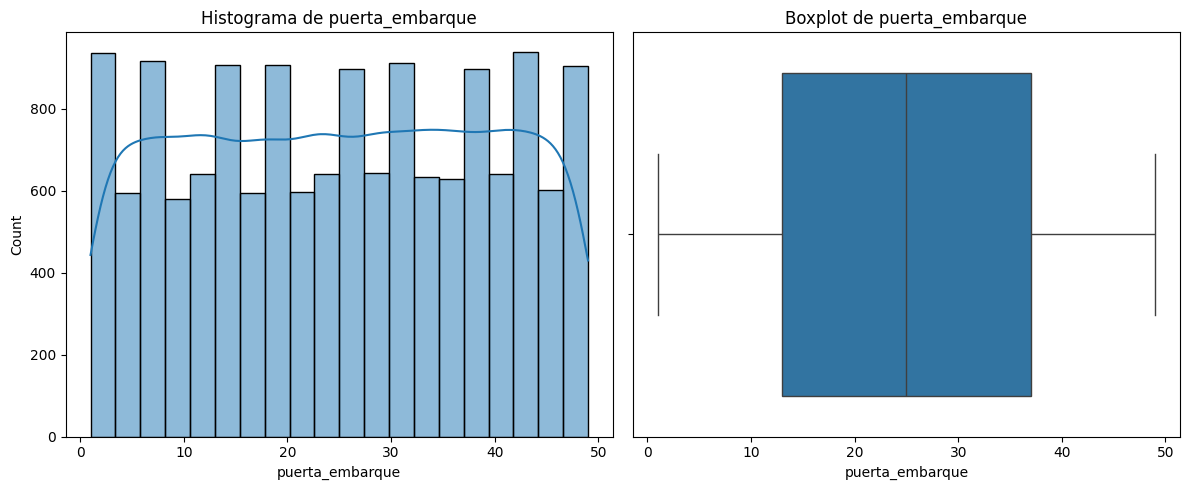

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(
    data=df,
    x='puerta_embarque',
    bins=20,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Histograma de puerta_embarque')

sns.boxplot(
    x=df['puerta_embarque'],
    ax=axes[1]
)

axes[1].set_title('Boxplot de puerta_embarque')

plt.tight_layout()
plt.show()

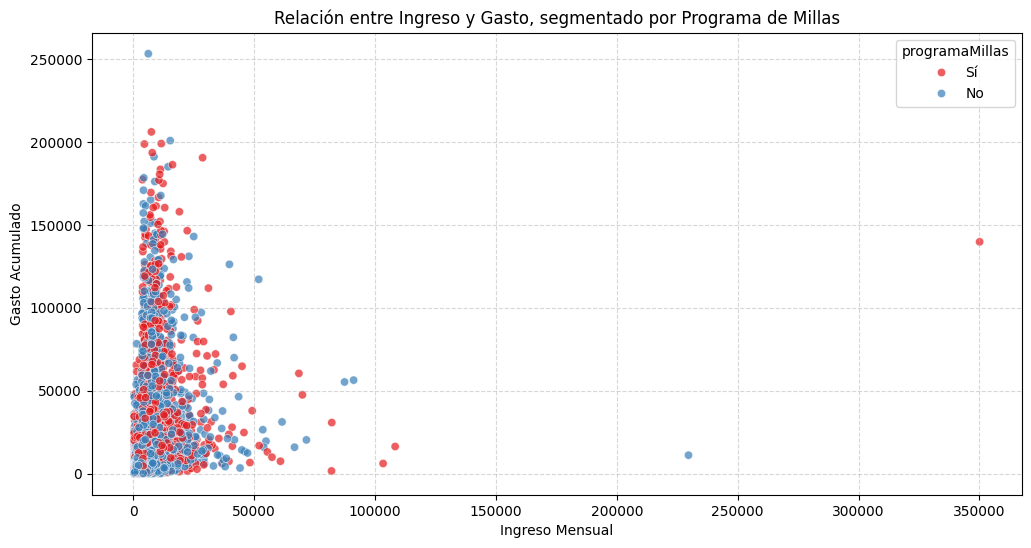

In [ ]:
# 2. SCATTERPLOT MULTIVARIABLE
# ==========================================
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=dfC,
    x='ingreso_mensual',
    y='gasto_acumulado',
    hue='programaMillas', # Esta es tu tercera variable
    palette='Set1',
    alpha=0.7 # Hace los puntos un poco transparentes por si se superponen
)
plt.title("Relación entre Ingreso y Gasto, segmentado por Programa de Millas")
plt.xlabel("Ingreso Mensual")
plt.ylabel("Gasto Acumulado")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# ==========================================
# 2. BARRAS AGRUPADAS: CATEGÓRICAS VS DEMORA
# ==========================================
# Seleccionamos las columnas categóricas relevantes
# (Asumiendo que corriste el código anterior para crear pais_origen y franja_horaria.
# Si no lo hiciste, cambia esas por aeropuerto_origen y hora_salida_programada)
cat_cols_vuelos = [
    'ocupacion'
]

# Filtramos solo las columnas que realmente existen en el dataframe en este momento
cat_cols_vuelos = [col for col in cat_cols_vuelos if col in dfC.columns]

print("\n--- GENERANDO GRÁFICOS DE BARRAS: CATEGÓRICAS VS DEMORA ---")
for col in cat_cols_vuelos:
    plt.figure(figsize=(12, 6))

    # countplot con hue='demora' separa las barras
    sns.countplot(
        data=dfC,
        x=col,
        y= 'ingreso_mensual',
        hue='clase_preferida',
        palette='Set1'
    )

    plt.title(f"Distribucion de clase preferida por ocupación", fontsize=14)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    plt.ylabel("Ingreso Mensual", fontsize=12)

    plt.xticks(rotation=45, ha='right')


    plt.tight_layout()
    plt.show()


--- GENERANDO GRÁFICOS DE BARRAS: CATEGÓRICAS VS DEMORA ---


TypeError: Cannot pass values for both `x` and `y`.

<Figure size 1200x600 with 0 Axes>

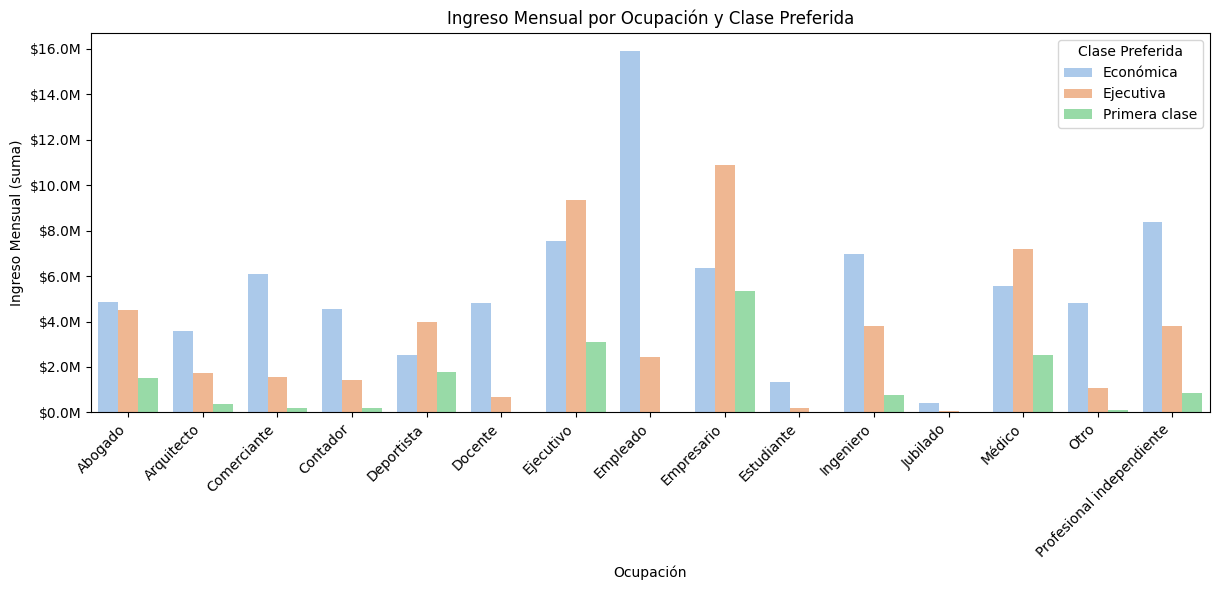

In [ ]:
from matplotlib.ticker import FuncFormatter
df_grouped = dfC.groupby(['ocupacion', 'clase_preferida'], as_index=False)['ingreso_mensual'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_grouped,
    x='ocupacion',
    y='ingreso_mensual',
    hue='clase_preferida',
    palette='pastel'
)
plt.title("Ingreso Mensual por Ocupación y Clase Preferida")
plt.xlabel("Ocupación")
plt.ylabel("Ingreso Mensual (suma)")
plt.legend(title='Clase Preferida')
plt.xticks(rotation=45, ha='right')  # útil si hay muchas categorías
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))
plt.show()

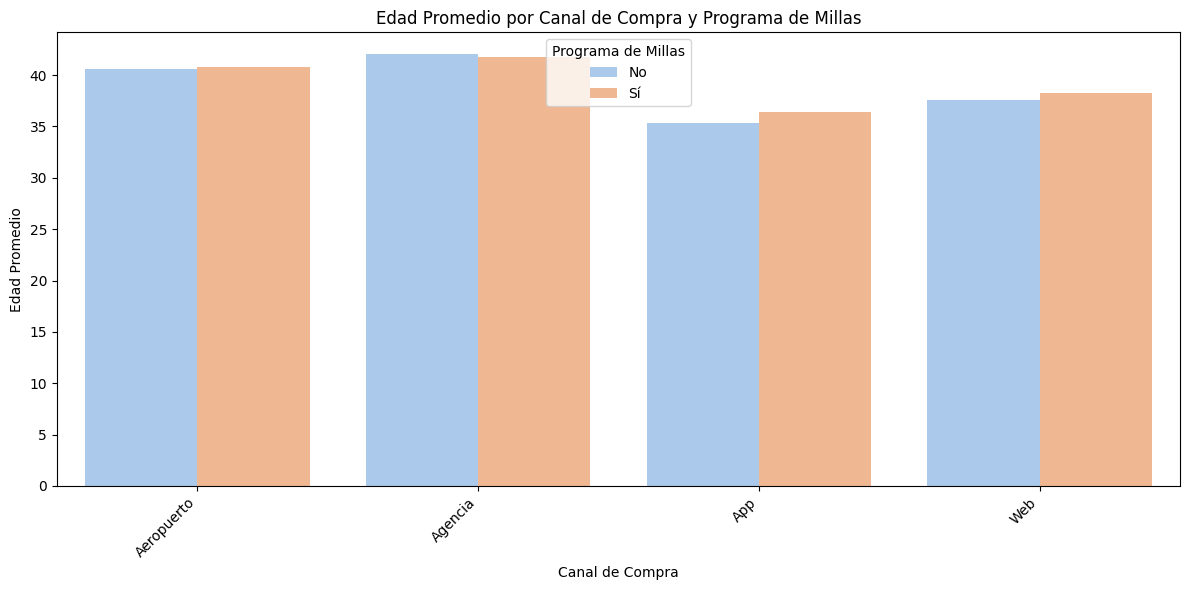

In [ ]:
df_grouped2 = dfC.groupby(['canal_compra', 'programaMillas'], as_index=False)['edad'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_grouped2,
    x='canal_compra',
    y='edad',
    hue='programaMillas',
    palette='pastel'
)
plt.title("Edad Promedio por Canal de Compra y Programa de Millas")
plt.xlabel("Canal de Compra")
plt.ylabel("Edad Promedio")
plt.legend(title='Programa de Millas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_13670/647872236.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


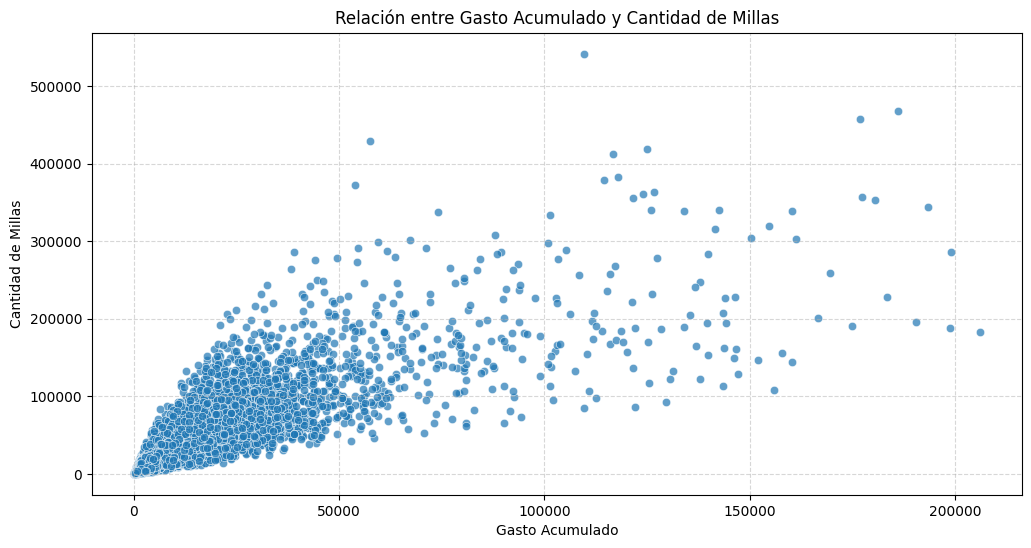

In [ ]:
df_scatter = dfC[dfC['cantidad_millas'] > 0]

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_scatter,
    x='gasto_acumulado',
    y='cantidad_millas',
    palette='Set1',
    alpha=0.7
)
plt.title("Relación entre Gasto Acumulado y Cantidad de Millas")
plt.xlabel("Gasto Acumulado")
plt.ylabel("Cantidad de Millas")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from matplotlib.ticker import FuncFormatter
df_grouped = dfC.groupby(['ocupacion', 'clase_preferida'], as_index=False)['ingreso_mensual'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_grouped,
    x='ocupacion',
    y='ingreso_mensual',
    hue='clase_preferida',
    palette='pastel'
)
plt.title("Ingreso Mensual por Ocupación y Clase Preferida")
plt.xlabel("Ocupación")
plt.ylabel("Ingreso Mensual (suma)")
plt.legend(title='Clase Preferida')
plt.xticks(rotation=45, ha='right')  # útil si hay muchas categorías
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))
plt.show()

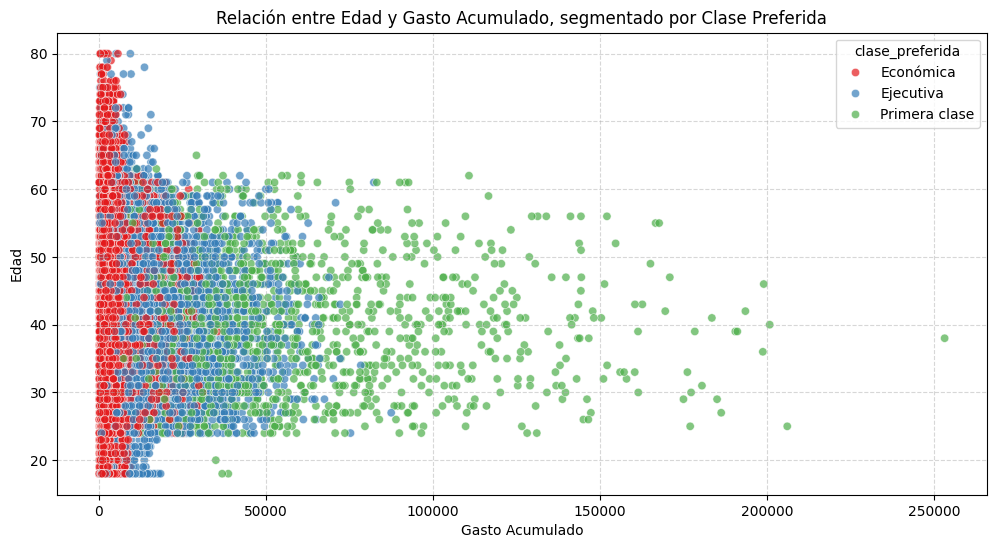

In [ ]:
# 2. SCATTERPLOT MULTIVARIABLE
# ==========================================
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=dfC,
    x='gasto_acumulado',
    y='edad',
    hue='clase_preferida', # Esta es tu tercera variable
    palette='Set1',
    alpha=0.7 # Hace los puntos un poco transparentes por si se superponen
)
plt.title("Relación entre Edad y Gasto Acumulado, segmentado por Clase Preferida")
plt.xlabel("Gasto Acumulado")
plt.ylabel("Edad")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

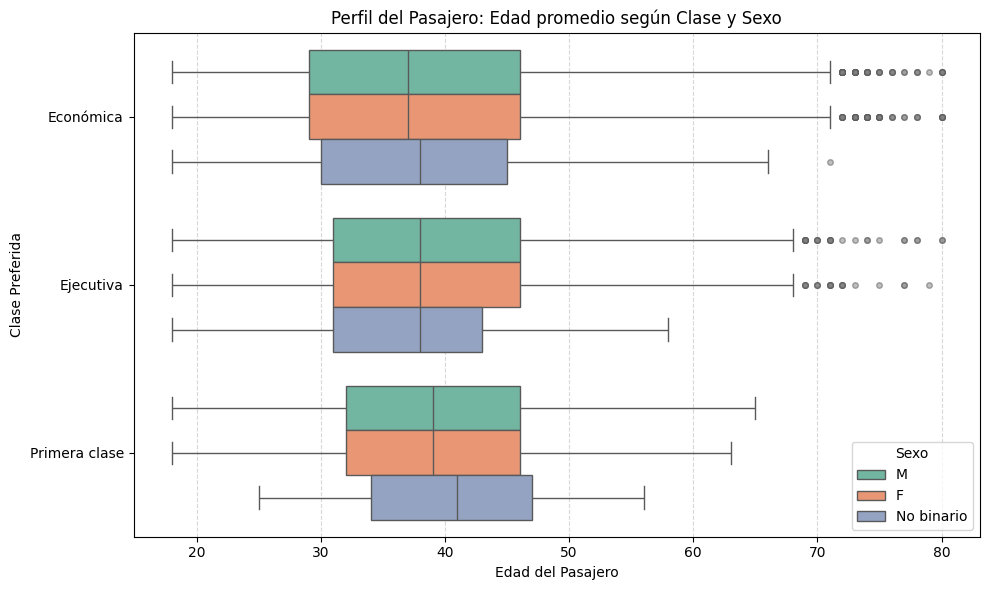

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=dfC,
    x='edad',
    y='clase_preferida',
    hue='sexo',
    palette='Set2',
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
)
plt.title("Perfil del Pasajero: Edad promedio según Clase y Sexo")
plt.xlabel("Edad del Pasajero")
plt.ylabel("Clase Preferida")
plt.legend(title='Sexo')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

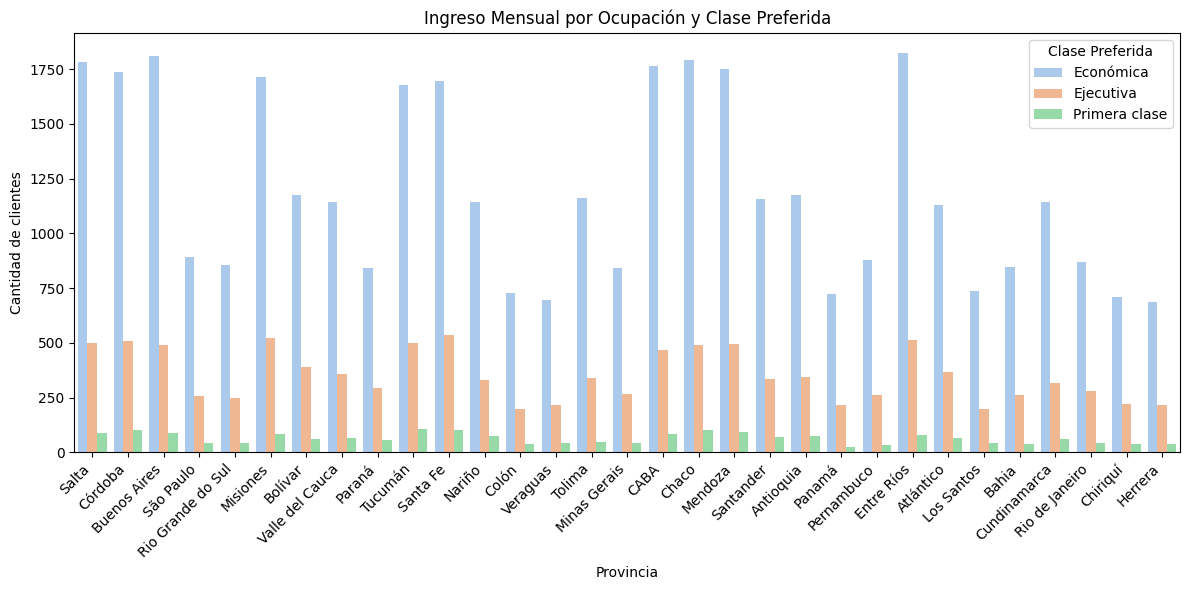

In [ ]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))
sns.countplot(
    data=dfC,
    x='provincia',
    hue='clase_preferida',
    palette='pastel'
)
plt.title("Ingreso Mensual por Ocupación y Clase Preferida")
plt.xlabel("Provincia")
plt.ylabel("Cantidad de clientes")
plt.legend(title='Clase Preferida')
plt.xticks(rotation=45, ha='right')  # útil si hay muchas categorías
plt.tight_layout()
plt.show()

In [35]:
mapeo_pais = {
    # Argentina
    'Buenos Aires': 'Argentina',
    'CABA': 'Argentina',
    'Córdoba': 'Argentina',
    'Santa Fe': 'Argentina',
    'Mendoza': 'Argentina',
    'Tucumán': 'Argentina',
    'Salta': 'Argentina',
    'Misiones': 'Argentina',
    'Chaco': 'Argentina',
    'Entre Ríos': 'Argentina',
    'Bolívar': 'Argentina',
    # Brasil
    'São Paulo': 'Brasil',
    'Rio de Janeiro': 'Brasil',
    'Rio Grande do Sul': 'Brasil',
    'Minas Gerais': 'Brasil',
    'Bahia': 'Brasil',
    'Paraná': 'Brasil',
    'Pernambuco': 'Brasil',
    # Colombia
    'Antioquia': 'Colombia',
    'Cundinamarca': 'Colombia',
    'Valle del Cauca': 'Colombia',
    'Atlántico': 'Colombia',
    'Santander': 'Colombia',
    'Nariño': 'Colombia',
    'Tolima': 'Colombia',
    # Panamá
    'Panamá': 'Panamá',
    'Chiriquí': 'Panamá',
    'Colón': 'Panamá',
    'Herrera': 'Panamá',
    'Los Santos': 'Panamá',
    'Veraguas': 'Panamá',
}

dfC['pais_origen'] = dfC['provincia'].map(mapeo_pais)
dfC = dfC.drop(columns='provincia')

In [36]:
dfC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_cliente                    50000 non-null  int64  
 1   sexo                          50000 non-null  object 
 2   edad                          50000 non-null  int64  
 3   ocupacion                     50000 non-null  object 
 4   cant_vuelos                   50000 non-null  int64  
 5   clase_preferida               50000 non-null  object 
 6   gasto_acumulado               50000 non-null  float64
 7   gasto_acumulado_extra         50000 non-null  float64
 8   programaMillas                50000 non-null  object 
 9   cantidad_millas               50000 non-null  int64  
 10  ingreso_mensual               50000 non-null  int64  
 11  anticipacion_compra_promedio  50000 non-null  int64  
 12  canal_compra                  50000 non-null  object 
 13  p

In [37]:
from google.colab import files

dfC.to_excel('dataset_transformado.xlsx', index=False)
files.download('dataset_transformado.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

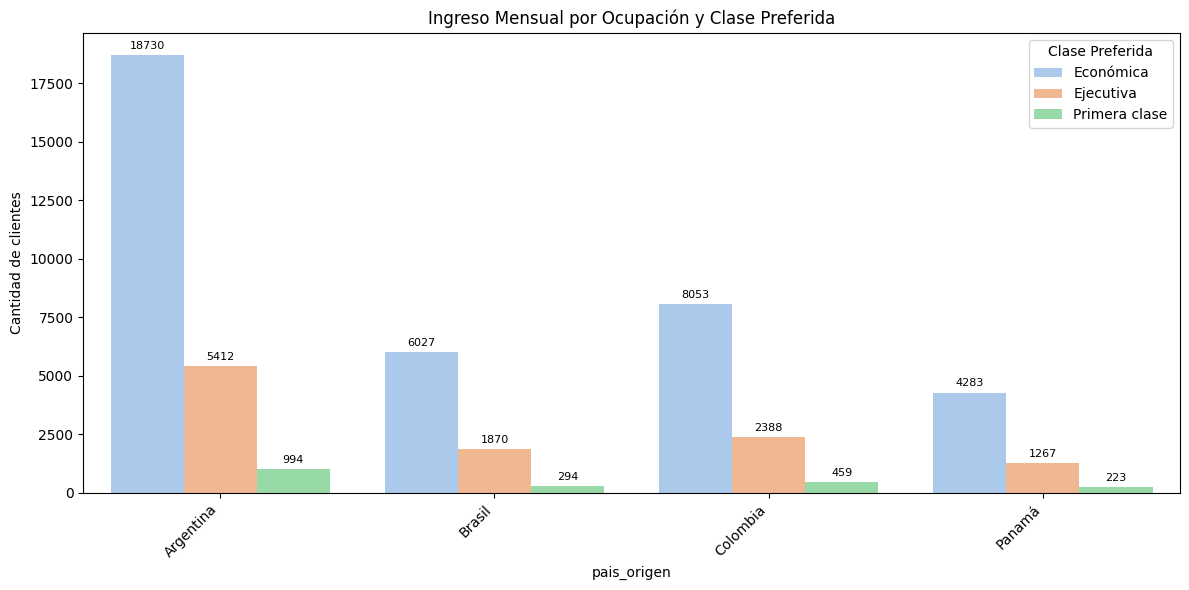

In [ ]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))
sns.countplot(
    data=dfC,
    x='pais_origen',
    hue='clase_preferida',
    palette='pastel'
)
plt.title("Ingreso Mensual por Ocupación y Clase Preferida")
plt.xlabel("pais_origen")
plt.ylabel("Cantidad de clientes")
plt.legend(title='Clase Preferida')
plt.xticks(rotation=45, ha='right')  # útil si hay muchas categorías
plt.tight_layout()
for container in plt.gca().containers:
    plt.gca().bar_label(container, fontsize=8, padding=3)
plt.show()